# 05 – Model Selection, Hyperparameter Tuning & Real-World Project (Preetham's Scikit-learn Mastery Series)

Welcome to **Part 5** – the grand capstone notebook of the Scikit-Learn Mastery Series! In this notebook, we bridge the gap between individual modeling tools and building end-to-end, production-ready Machine Learning workflows.

---

### 📌 What You Will Master in This Capstone Notebook:
1. **Exhaustive Grid Search (`GridSearchCV`)**: Systematic hyperparameter tuning with cross-validation.
2. **Randomized Search (`RandomizedSearchCV`)**: Efficient hyperparameter optimization over continuous probability distributions.
3. **Heterogeneous Preprocessing (`ColumnTransformer`)**: Handling numerical, ordinal, and nominal categorical features simultaneously without data leakage.
4. **Diagnostic Learning Curves**: Diagnosing high bias (underfitting) vs high variance (overfitting).
5. **Validation Curves**: Evaluating hyperparameter sensitivity across parameter ranges.
6. **Cap-stone Real-World Mini Project**: Complete pipeline design, evaluation, confusion matrix visualizer, and model persistence with `joblib`.


In [2]:
# Setup, reproducible seeds, and dataset preparation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

# Load Wine dataset
wine = datasets.load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
target_names = wine.target_names

# Train-test split (80% train, 20% test, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Dataset Split Completed:")
print(f"Training Set : {X_train.shape[0]} samples")
print(f"Test Set     : {X_test.shape[0]} samples")
print(f"Class Proportions in Test: {np.bincount(y_test)}")


Dataset Split Completed:
Training Set : 142 samples
Test Set     : 36 samples
Class Proportions in Test: [12 14 10]


---
## 1. `GridSearchCV` – Systematic Exhaustive Hyperparameter Tuning

`GridSearchCV` performs an exhaustive search over a specified parameter grid, evaluating every candidate combination using $K$-fold cross-validation.

### 📐 Mathematical Complexity
For a parameter grid with $M_1, M_2, \dots, M_p$ candidate values per hyperparameter and $K$ folds:

$$\text{Total Fits} = K \times \prod_{i=1}^{p} M_i$$

For Support Vector Classification (`SVC`), common hyperparameters include:
- `C`: Regularization strength (inverse penalty).
- `kernel`: Projection function (`'rbf'`, `'linear'`, `'poly'`).
- `gamma`: Kernel coefficient for `'rbf'`.


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Define Pipeline inside GridSearchCV to eliminate data leakage during cross-validation
pipe_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

# Define Search Grid
param_grid_svc = {
    'svc__C': [0.1, 1.0, 10.0, 100.0],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1],
    'svc__kernel': ['rbf', 'linear']
}

# Run GridSearchCV
grid_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid_svc.fit(X_train, y_train)

print("GridSearchCV Results:")
print(f"Total Combinations Evaluated: {len(grid_svc.cv_results_['params'])}")
print(f"Best CV Accuracy Score     : {grid_svc.best_score_:.4f}")
print(f"Best Hyperparameters Found : {grid_svc.best_params_}")


GridSearchCV Results:
Total Combinations Evaluated: 32
Best CV Accuracy Score     : 0.9931
Best Hyperparameters Found : {'svc__C': 1.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


### 📊 Visualizing Grid Search Results Heatmap
Inspecting cross-validation scores across parameter combinations allows us to verify if our search grid was appropriately bounded or if optimal parameters sit on the boundary.


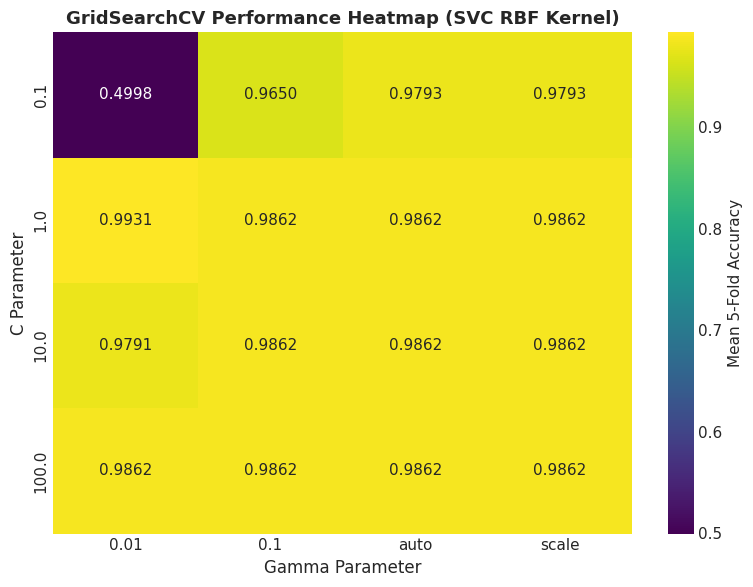

In [6]:
# Extract results for RBF kernel combinations
results_df = pd.DataFrame(grid_svc.cv_results_)
rbf_mask = results_df['param_svc__kernel'] == 'rbf'
pivot_scores = results_df[rbf_mask].pivot(
    index='param_svc__C',
    columns='param_svc__gamma',
    values='mean_test_score'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_scores, annot=True, fmt=".4f", cmap="viridis", cbar_kws={'label': 'Mean 5-Fold Accuracy'})
plt.title("GridSearchCV Performance Heatmap (SVC RBF Kernel)", fontsize=13, fontweight='bold')
plt.xlabel("Gamma Parameter", fontsize=12)
plt.ylabel("C Parameter", fontsize=12)
plt.tight_layout()
plt.show()


---
## 2. `RandomizedSearchCV` – Efficient Search Over Large Continuous Spaces

When parameter search space is high-dimensional or continuous, exhaustive grid search becomes computationally prohibitive. **`RandomizedSearchCV`** samples a fixed number of combinations (`n_iter`) from specified probability distributions.

### 💡 Why Randomized Search Wins:
Bergstra & Bengio (2012) proved that randomized search is significantly more efficient because not all hyperparameters are equally important for a given dataset.


In [8]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Continuous & Discrete Parameter Distributions
param_dist_rf = {
    'rf__n_estimators': randint(50, 300),
    'rf__max_depth': [None, 5, 10, 15, 20],
    'rf__min_samples_split': randint(2, 11),
    'rf__min_samples_leaf': randint(1, 5),
    'rf__max_features': ['sqrt', 'log2', None]
}

# Run RandomizedSearchCV (Sampling 30 random configurations)
random_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

print("RandomizedSearchCV Results:")
print("Iterations Evaluated      : 30 / Thousands of possible combinations")
print(f"Best CV Accuracy Score    : {random_rf.best_score_:.4f}")
print(f"Best Hyperparameters Found: {random_rf.best_params_}")


RandomizedSearchCV Results:
Iterations Evaluated      : 30 / Thousands of possible combinations
Best CV Accuracy Score    : 0.9862
Best Hyperparameters Found: {'rf__max_depth': 10, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 3, 'rf__n_estimators': 137}


---
## 3. `ColumnTransformer` – Heterogeneous Data Preprocessing

Real-world tabular data contains mixed column types: **numerical**, **nominal categorical**, and **ordinal categorical**. Applying different transformations to different columns without leaking data requires **`ColumnTransformer`**.


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Create synthetic mixed-type tabular dataset
np.random.seed(42)
n_samples = 200

df_mixed = pd.DataFrame({
    'age': np.random.randint(18, 70, size=n_samples).astype(float),
    'income': np.random.normal(50000, 15000, size=n_samples),
    'city': np.random.choice(['New York', 'Paris', 'Tokyo', 'London'], size=n_samples),
    'education': np.random.choice(['HighSchool', 'Bachelors', 'Masters', 'PhD'], size=n_samples),
    'purchased': np.random.choice([0, 1], size=n_samples)
})

# Add some missing values
df_mixed.loc[10:15, 'age'] = np.nan
df_mixed.loc[30:35, 'city'] = np.nan

X_mix = df_mixed.drop('purchased', axis=1)
y_mix = df_mixed['purchased']

# Define column groups
num_cols = ['age', 'income']
cat_cols = ['city', 'education']

# Numerical Pipeline: Impute Median -> Scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Impute Mode -> OneHotEncode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_mix_processed = preprocessor.fit_transform(X_mix)
print(f"Original Input DataFrame Shape: {X_mix.shape}")
print(f"Processed Dense Array Shape   : {X_mix_processed.shape}")


Original Input DataFrame Shape: (200, 4)
Processed Dense Array Shape   : (200, 10)


---
## 4. Learning Curves – Diagnosing Underfitting vs Overfitting

A **learning curve** plots training score and validation score against increasing training set sizes.

### 🔍 Diagnostic Rules:
- **High Bias (Underfitting)**: Both training and validation scores plateau at an unacceptably low accuracy. Gap between curves is small.
- **High Variance (Overfitting)**: Training score is high, but validation score is significantly lower. Large gap between curves.


Final Validation Accuracy at 100% Training Size: 0.9931
Generalization Gap (Train - Val)             : -0.0037


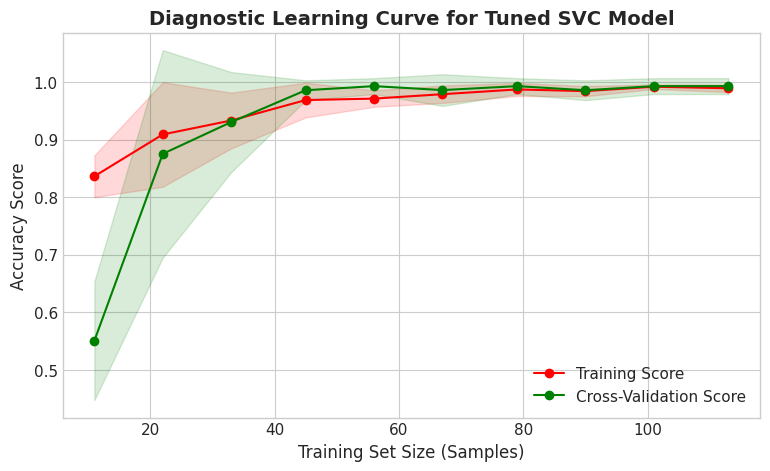

In [12]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=grid_svc.best_estimator_,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='r')

plt.plot(train_sizes, val_mean, 'o-', color='g', label='Cross-Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='g')

plt.xlabel('Training Set Size (Samples)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Diagnostic Learning Curve for Tuned SVC Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Final Validation Accuracy at 100% Training Size: {val_mean[-1]:.4f}")
print(f"Generalization Gap (Train - Val)             : {train_mean[-1] - val_mean[-1]:.4f}")


---
## 5. Capstone Real-World Mini Project: End-to-End Pipeline & Deployment

Now we combine all 5 notebooks of knowledge to execute a complete end-to-end Machine Learning project on held-out test data.

### 🏆 Workflow:
1. Split into train & held-out test sets.
2. Build full pipeline with scaler, PCA dimensionality reduction, and Random Forest classifier.
3. Perform hyperparameter tuning via `GridSearchCV` on train set.
4. Evaluate best estimator on held-out test set (Classification report, Confusion Matrix, ROC-AUC).
5. Persist model to disk using `joblib`.


Best Cross-Validation Score : 0.9791
Held-Out Test Set Accuracy  : 0.9444
Detailed Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      0.92      0.92        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.94        36
   macro avg       0.95      0.95      0.95        36
weighted avg       0.94      0.94      0.94        36

Model artifact saved successfully as 'wine_capstone_pipeline.joblib'!
Reloaded model verification check: True


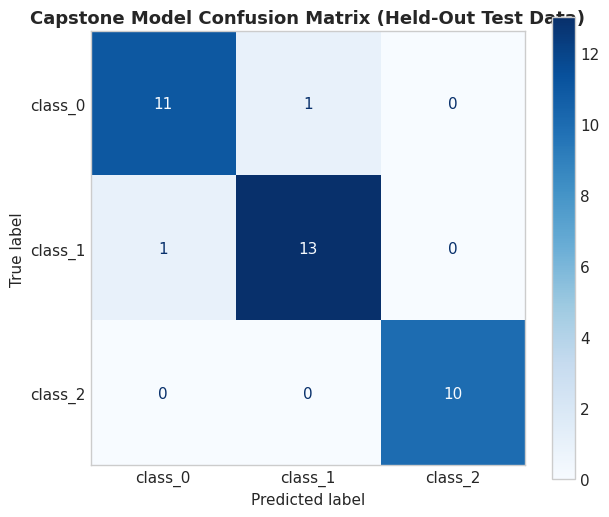

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import joblib

# Step 1: Define Full Capstone Pipeline
capstone_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Step 2: Grid Search Tuning
param_grid_capstone = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, None],
    'classifier__criterion': ['gini', 'entropy']
}

grid_capstone = GridSearchCV(
    estimator=capstone_pipeline,
    param_grid=param_grid_capstone,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_capstone.fit(X_train, y_train)
best_model = grid_capstone.best_estimator_

# Step 3: Evaluate on Held-Out Test Set
test_preds = best_model.predict(X_test)
test_accuracy = best_model.score(X_test, y_test)

print(f"Best Cross-Validation Score : {grid_capstone.best_score_:.4f}")
print(f"Held-Out Test Set Accuracy  : {test_accuracy:.4f}")
print("Detailed Classification Report:")
print(classification_report(y_test, test_preds, target_names=target_names))

# Step 4: Plot Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
plt.title("Capstone Model Confusion Matrix (Held-Out Test Data)", fontsize=13, fontweight='bold')
plt.grid(False)
plt.show()

# Step 5: Save Model Artifact
model_filename = 'wine_capstone_pipeline.joblib'
joblib.dump(best_model, model_filename)
print(f"Model artifact saved successfully as '{model_filename}'!")

# Step 6: Verify Model Loading
loaded_model = joblib.load(model_filename)
reloaded_preds = loaded_model.predict(X_test)
print(f"Reloaded model verification check: {np.array_equal(test_preds, reloaded_preds)}")


---
## 6. Complete Scikit-Learn Mastery Series Summary

Congratulations! You have completed the entire 5-notebook **Scikit-Learn Mastery Series**:

1. **`01_sklearn_basics.ipynb`**: Estimator API (`fit`, `transform`, `predict`), dataset loading, standard scaling, and basic train-test splits.
2. **`02_classification.ipynb`**: Logistic Regression, Decision Trees, Random Forests, Support Vector Machines, ROC-AUC curves, PR curves, and class imbalance handling (SMOTE, class weights).
3. **`03_regression.ipynb`**: Linear Regression, Ridge ($L_2$), Lasso ($L_1$), ElasticNet, Decision Tree Regressors, MSE/RMSE/MAE/$R^2$ metrics, and residual analysis.
4. **`04_unsupervised_preprocessing.ipynb`**: K-Means, Hierarchical Dendrograms, DBSCAN density clustering, PCA, t-SNE, Feature Selection (`SelectKBest`, `RFE`), Imputation (`Simple`, `KNN`, `Iterative`), and Anomaly Detection (`IsolationForest`, `LOF`).
5. **`05_model_selection_project.ipynb`**: `GridSearchCV`, `RandomizedSearchCV`, `ColumnTransformer`, Learning Curves, End-to-End Capstone Project, and Model Persistence (`joblib`).

---
### 🎓 You are now fully equipped to build, tune, validate, and deploy end-to-end Machine Learning systems in Python with Scikit-Learn!
